# Importing Relevant Libraries

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.stattools import durbin_watson

# Importing the dataset and understanding it 

In [4]:
df_init = pd.read_csv("Advertising.csv")
df_init.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## Checking for missing values and duplicates

In [6]:
df_init.isna().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [7]:
df_init.duplicated().sum()

0

Key Insights
- There are no missing values and neither are there duplicates.

In [9]:
df_init.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [10]:
df_init.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [11]:
df1 = df_init[["TV", "Radio", "Newspaper", "Sales"]].copy()

In [12]:
df1.shape

(200, 4)

## Getting Descriptive Statistics 

In [14]:
df1.describe(include="all")

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


Key Insights
- The counts are consistent with no missing values.
- For the TV:
    - 147.04 is spent via TV advertisement if you pick an advert at random.
- Radio:
    - 23.26 is spent via Radio advertisement if you pick an advert at random.
- Newspaper:
    - 30.55 is spent via Newspaper advertisement if you pick an advert at random.

- People spend more on Television advertisements on average as compared to Radio and Newspapers.
- The distributions of each advertisement are approximately normal given the closeness of the means and the respective medians. Radio and Newspaper adverts show signs of right skewness and probable presence of extreme values.

## Checking for outliers 

Text(0, 0.5, '')

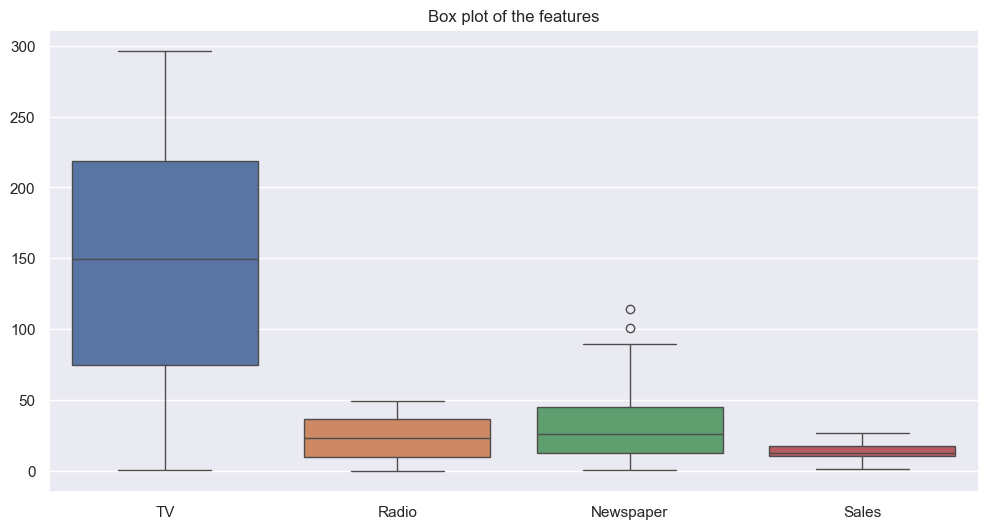

In [17]:
plt.figure(figsize=(12,6))
sns.boxplot(df1)
plt.title("Box plot of the features")
plt.xlabel("")
plt.ylabel("")

In [18]:
Q1 = df1["Newspaper"].quantile(0.25)
Q3 = df1["Newspaper"].quantile(0.75)
IQR = Q3-Q1

upper_bound = Q3 + 1.5*IQR

upper_bound

93.625

In [19]:
newpaper_outliers = df1[df1["Newspaper"]>upper_bound]

newpaper_outliers

,TV,Radio,Newspaper,Sales
16,67.8,36.6,114.0,12.5
101,296.4,36.3,100.9,23.8


### Using the winsorizing technique to cap the outliers 

In [21]:
df = df1.copy()

df["Newspaper"] = np.where(
    df1["Newspaper"]>upper_bound,
    upper_bound,
    df["Newspaper"]
)

## Plotting pairplots 

<Figure size 1200x800 with 0 Axes>

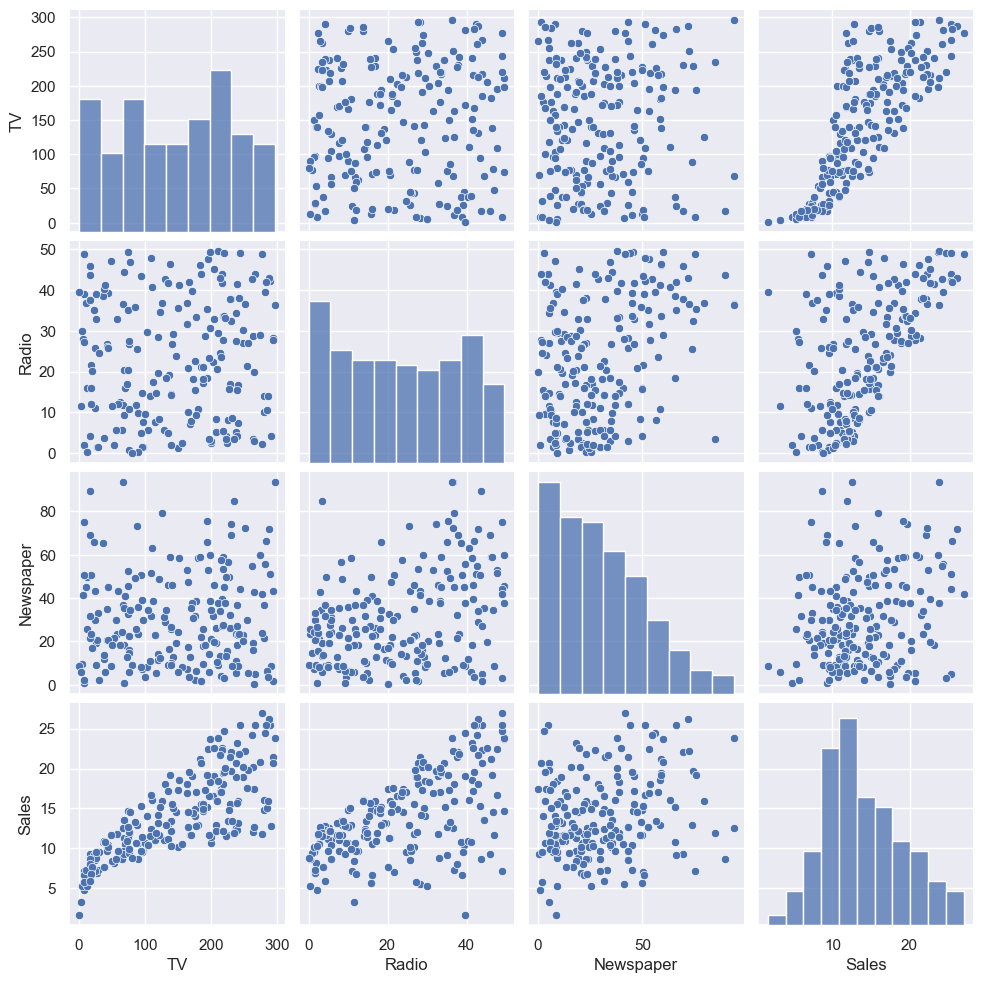

In [23]:
plt.figure(figsize=(12,8))
sns.pairplot(df)
plt.show()

Key insights
- There is a positive linear relationship between sales and TV, Radio, and Newspaper advertisement.
- The more the TV adverts, the more the sales. This is the same for Radio adverts.
- The Radio, Newspapers and TV sales have an inconsistent variance forming funnels.
- Newspaper adverts on the other hand have very low linear relationship with the sales.

## Scatter plots

### Scatter Plot for sales vs TV, Radio, and Newspaper adverts 

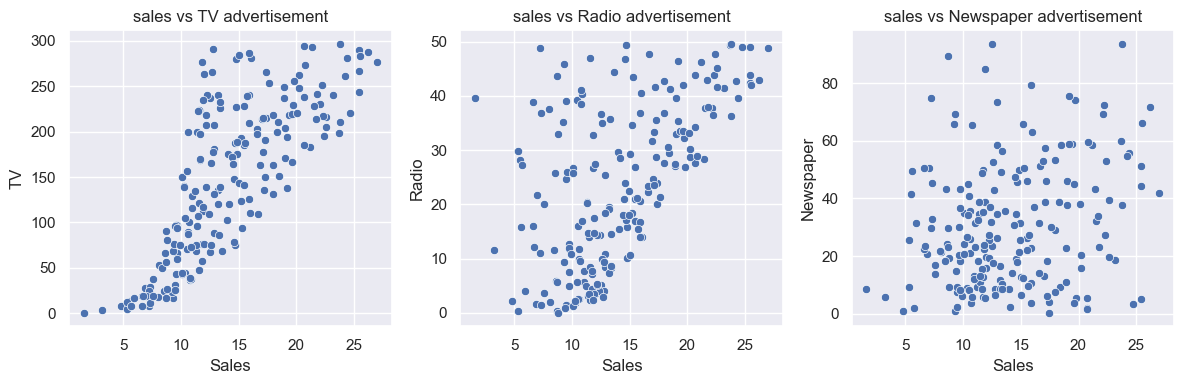

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(12,4))

sns.scatterplot(data=df, x="Sales", y="TV", ax=axes[0])
axes[0].set_title("sales vs TV advertisement")

sns.scatterplot(data=df, x="Sales", y="Radio", ax=axes[1])
axes[1].set_title("sales vs Radio advertisement")

sns.scatterplot(data=df, x="Sales", y="Newspaper")
axes[2].set_title("sales vs Newspaper advertisement")

plt.tight_layout()
plt.show()

## Heatmap

In [30]:
cor_matrix = df.corr()

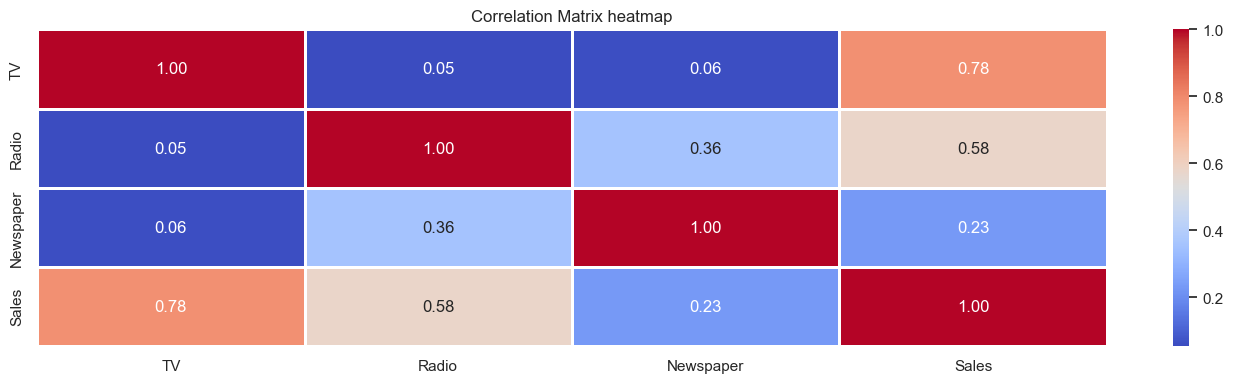

In [31]:
plt.figure(figsize=(14,4))
sns.heatmap(
    cor_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidth=1,
    cbar=True
)
plt.title("Correlation Matrix heatmap")
plt.tight_layout()
plt.show()

- This confirms the low linear relationship with the newspaper adverts

# Fitting the linear model

## 80/20 split

In [35]:
X = df.drop(columns=["Sales"])
y = df["Sales"]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=256
)

lr = LinearRegression()
lr = lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [37]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

In [38]:
print(f"R_squared : {lr_r2:.4f}")
print(f"RMSE : {lr_rmse:.4f}")
print(f"MAE : {lr_mae:.4f}")

R_squared : 0.8461
RMSE : 1.7672
MAE : 1.2978


## Checking model assumptions

### Linearity

In [41]:
y_train_pred = lr.predict(X_train)
residuals = y_train - y_train_pred

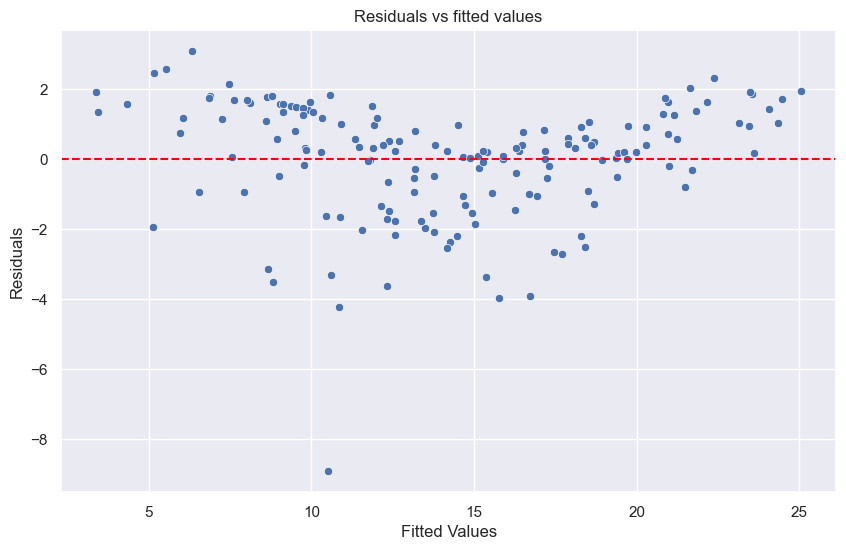

In [42]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_train_pred, y=residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs fitted values")
plt.show() 

### Normality of residuals 

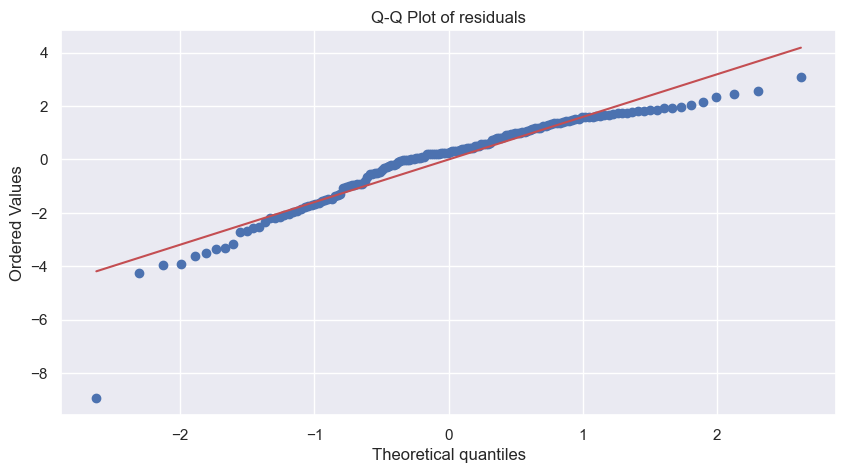

In [44]:
plt.figure(figsize=(10,5))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of residuals")
plt.show()

In [45]:
stat, p_value = stats.shapiro(residuals)
print(f"Shapiro-Wilk Statistic: {stat:.4f}, P_value: {p_value:.4f}")

Shapiro-Wilk Statistic: 0.9079, P_value: 0.0000


- The residuals are not normally distributed.
- The downward bending shows heteroscedasticity and evidence of a non linear relationship.
- This suggests transformation may be needed or use of polynomial terms

### Multicollinearity (VIF) 

In [48]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i) for i in range(X.shape[1])
]

print(vif_data)

     Feature       VIF
0         TV  2.500402
1      Radio  3.304735
2  Newspaper  3.115816


There is no evidence of Multicollinearity

### Independence of residuals 

In [51]:
dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson Statistic: {dw_stat:.4f}")

Durbin-Watson Statistic: 2.0097


The residuals are independent

## Remodelling with interaction terms after centering including polynomial terms of at most degree 2

In [54]:
poly_inter = PolynomialFeatures(degree=2, include_bias=False)

In [119]:
scaler =StandardScaler(with_mean=True, with_std=True)

X_train_centered = scaler.fit_transform(X_train)
X_test_centered = scaler.transform(X_test)

X_train_inter = poly_inter.fit_transform(X_train_centered)
X_test_inter = poly_inter.transform(X_test_centered)

lr_inter =LinearRegression()
lr_inter.fit(X_train_inter, y_train)

lr_inter_pred = lr_inter.predict(X_test_inter)

In [56]:
mae_inter = mean_absolute_error(y_test, lr_inter_pred)
rmse = np.sqrt(mean_squared_error(y_test, lr_inter_pred))
rs_inter = r2_score(y_test, lr_inter_pred)

In [57]:
print(f"R_squared : {rs_inter:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE : {mae_inter:.4f}")

R_squared : 0.9867
RMSE : 0.5198
MAE : 0.4349


In [58]:
feature_names = poly_inter.get_feature_names_out(X.columns)
print(feature_names)

['TV' 'Radio' 'Newspaper' 'TV^2' 'TV Radio' 'TV Newspaper' 'Radio^2'
 'Radio Newspaper' 'Newspaper^2']


In [59]:
residuals_inter = y_test - lr_inter_pred

## Rechecking the assumptions 

### Linearity

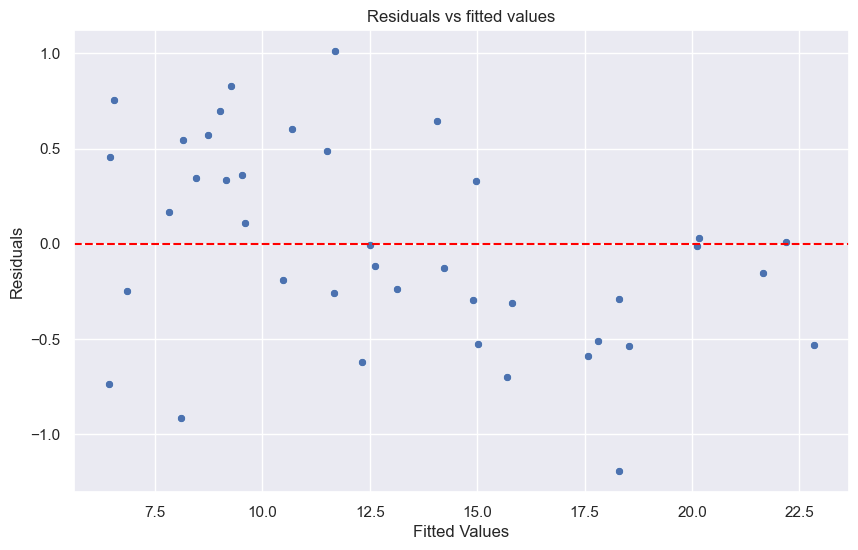

In [62]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=lr_inter_pred, y=residuals_inter)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs fitted values")
plt.show() 

### Normality

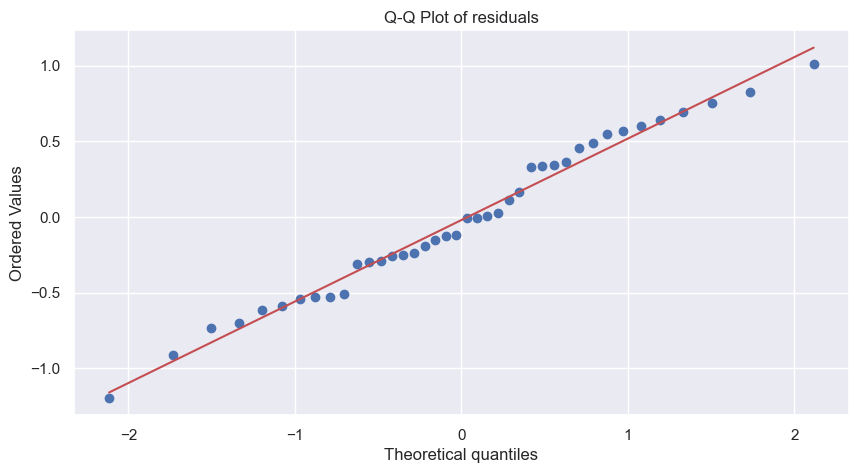

In [64]:
plt.figure(figsize=(10,5))
stats.probplot(residuals_inter, dist="norm", plot=plt)
plt.title("Q-Q Plot of residuals")
plt.show()

In [65]:
stat, p_value = stats.shapiro(residuals_inter)
print(f"Shapiro-Wilk Statistic: {stat:.4f}, P_value: {p_value:.4f}")

Shapiro-Wilk Statistic: 0.9812, P_value: 0.7328


- The residuals are normally distributed.

### Multicollinearity

In [68]:
vif_inter = pd.DataFrame()
vif_inter["Feature"] = feature_names
vif_inter["VIF"] = [
    variance_inflation_factor(X_train_inter, i)
    for i in range(X_train_inter.shape[1])
]

print(vif_inter)

           Feature       VIF
0               TV  1.047394
1            Radio  1.145093
2        Newspaper  1.511464
3             TV^2  1.794001
4         TV Radio  1.231726
5     TV Newspaper  1.236153
6          Radio^2  1.674430
7  Radio Newspaper  1.415220
8      Newspaper^2  2.094311


- There is no evidence of multicollinearity

## Generating a similar model output to statsmodel

In [130]:
# Convert the transformed numpy array back to a DataFrame
X_train_inter_df = pd.DataFrame(X_train_inter, columns=feature_names, index=X_train.index)

# Add a constant
X_train_sm = sm.add_constant(X_train_inter_df)

ols_model = sm.OLS(y_train, X_train_sm).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     1188.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):          1.27e-134
Time:                        11:44:33   Log-Likelihood:                -152.57
No. Observations:                 160   AIC:                             325.1
Df Residuals:                     150   BIC:                             355.9
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              15.0065      0.107    1

## Regularization for feature selection

# Fitting the Random Forest Regressor

In [71]:
rf = RandomForestRegressor(n_estimators=100, random_state=256)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [72]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

In [73]:
print(f"R_squared : {rf_r2:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"MAE : {rf_mae:.4f}")

R_squared : 0.9797
RMSE : 0.6426
MAE : 0.4808
